# 03 — Technical Analysis Engine

Phase 3 of the Indian Equity AI project plan.

Builds the full technical-indicator set (trend, momentum, volatility, volume) for all
5 stocks, and combines them into a single 0-100 Technical Score.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing.clean import validate_ohlcv
from src.technical.indicators import add_technical_indicators
from src.technical.score import technical_score

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
from src.config import UNIVERSE  # Phase 14: centralized, now 50 stocks

## Step 0: Load Phase 1 output

In [2]:
universe = pd.read_parquet(DATA_PROCESSED / "prices_daily.parquet")[
    ["date", "symbol", "open", "high", "low", "close", "adjusted_close", "volume"]
]
assert validate_ohlcv(universe) == {
    "missing_values": 0,
    "duplicate_rows": 0,
    "non_positive_prices": 0,
    "negative_volume": 0,
    "high_below_low": 0,
}
universe.shape

(61999, 8)

## Step 1: Compute all technical indicators, per symbol

In [3]:
technical = add_technical_indicators(universe)
technical.columns.tolist()

['date',
 'symbol',
 'open',
 'high',
 'low',
 'close',
 'adjusted_close',
 'volume',
 'sma_20',
 'sma_50',
 'sma_100',
 'sma_200',
 'ema_20',
 'ema_50',
 'rsi_14',
 'macd',
 'macd_signal',
 'macd_histogram',
 'roc_12',
 'stoch_k',
 'stoch_d',
 'adx_14',
 'atr_14',
 'bb_middle',
 'bb_upper',
 'bb_lower',
 'bb_width',
 'volume_ma_20',
 'volume_ratio',
 'obv',
 'vwap_20']

In [4]:
technical[technical["symbol"] == "RELIANCE"][
    ["date", "close", "sma_50", "sma_200", "rsi_14", "macd", "atr_14", "bb_width", "volume_ratio"]
].tail()

,date,close,sma_50,sma_200,rsi_14,macd,atr_14,bb_width,volume_ratio
47114,2026-09-22,1240.400024,1293.354001,1371.870502,38.642106,-18.102494,19.487326,0.092761,0.949014
47115,2026-09-23,1248.000000,1292.404001,1370.395502,41.539933,-17.421992,19.088233,0.093105,0.733358
47116,2026-09-24,1219.199951,1290.856001,1368.844502,34.827370,-18.987734,19.781934,0.100163,1.208517
47117,2026-09-25,1226.000000,1288.832002,1367.290002,37.399562,-19.455616,19.576083,0.103904,1.109989
47118,2026-09-28,1197.599976,1286.322002,1365.553002,31.761492,-21.866003,20.249220,0.114531,1.262589


## Step 2: Combine into a single Technical Score (0-100)

In [5]:
technical["technical_score"] = technical_score(technical)
technical.groupby("symbol")["technical_score"].agg(["mean", "min", "max"])

,mean,min,max
symbol,,,
ADANIENT,50.647232,12.040690,97.425535
ADANIPORTS,56.151777,17.069566,95.320219
APOLLOHOSP,58.733141,12.734967,92.720518
ASIANPAINT,48.951817,14.310296,94.936593
AXISBANK,57.224785,15.705149,92.777284
BAJAJ-AUTO,57.936940,10.396292,95.571423
BAJAJFINSV,53.039575,14.289619,89.926312
BAJFINANCE,52.311534,17.634353,92.816014
BHARTIARTL,59.100380,13.593005,93.635584


## Step 3: Visualize price with SMA/EMA and the resulting Technical Score

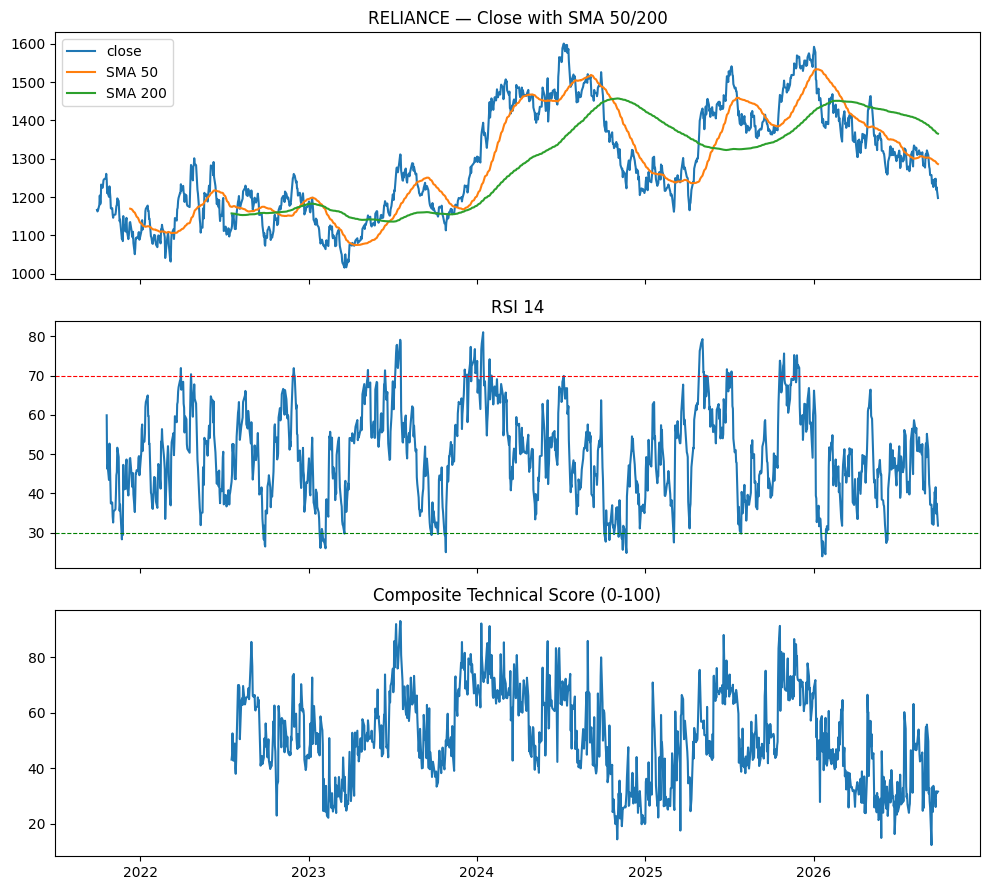

In [6]:
sample = technical[technical["symbol"] == "RELIANCE"].sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(sample["date"], sample["close"], label="close")
axes[0].plot(sample["date"], sample["sma_50"], label="SMA 50")
axes[0].plot(sample["date"], sample["sma_200"], label="SMA 200")
axes[0].legend()
axes[0].set_title("RELIANCE — Close with SMA 50/200")

axes[1].plot(sample["date"], sample["rsi_14"], label="RSI 14")
axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8)
axes[1].set_title("RSI 14")

axes[2].plot(sample["date"], sample["technical_score"], label="Technical Score")
axes[2].set_title("Composite Technical Score (0-100)")

plt.tight_layout()
plt.show()

## Step 4: Save technical features

In [7]:
technical.to_parquet(DATA_PROCESSED / "technical_features.parquet", index=False)
print("Saved:", DATA_PROCESSED / "technical_features.parquet")
print("Rows:", len(technical), "Symbols:", technical["symbol"].nunique())

Saved: D:\Practise\Stock Market Analysis\data\processed\technical_features.parquet
Rows: 61999 Symbols: 50
